In [6]:
import os

dataset_path = r"C:\Users\Admin\Downloads\archive (13)\plantvillage dataset\color"

In [7]:
# Checking the classes
classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two

In [8]:
# Checking the number of images per class
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

Apple___Apple_scab : 630
Apple___Black_rot : 621
Apple___Cedar_apple_rust : 275
Apple___healthy : 1645
Blueberry___healthy : 1502
Cherry_(including_sour)___healthy : 854
Cherry_(including_sour)___Powdery_mildew : 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513
Corn_(maize)___Common_rust_ : 1192
Corn_(maize)___healthy : 1162
Corn_(maize)___Northern_Leaf_Blight : 985
Grape___Black_rot : 1180
Grape___Esca_(Black_Measles) : 1383
Grape___healthy : 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1076
Orange___Haunglongbing_(Citrus_greening) : 5507
Peach___Bacterial_spot : 2297
Peach___healthy : 360
Pepper,_bell___Bacterial_spot : 997
Pepper,_bell___healthy : 1478
Potato___Early_blight : 1000
Potato___healthy : 152
Potato___Late_blight : 1000
Raspberry___healthy : 371
Soybean___healthy : 5090
Squash___Powdery_mildew : 1835
Strawberry___healthy : 456
Strawberry___Leaf_scorch : 1109
Tomato___Bacterial_spot : 2127
Tomato___Early_blight : 1000
Tomato___healthy : 1591
Tomato___Late_

In [9]:
# Total number of images
total_images = 0

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

print("Total images:", total_images)

Total images: 54305


- The dataset has `38` classes and `54305` images.
- Both contain healthy and diseased plants. 
- The classes are somewhat imbalanced i.e:
    - Potato_healthy has only **152** images.
    - Orange_Haunglongbing has **5,507** images.

**EDA**

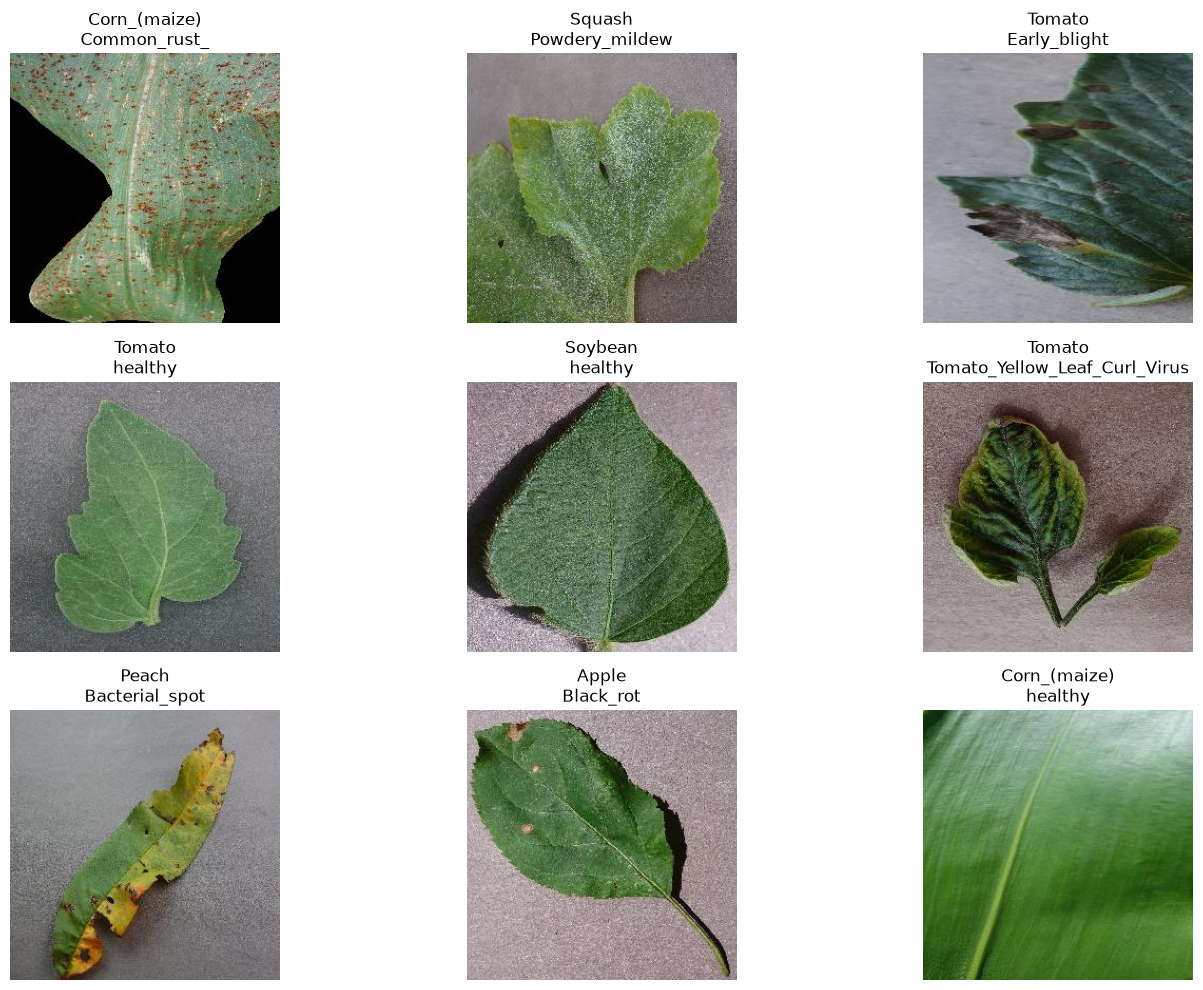

In [10]:
# Looking at one image from several classes
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(random.sample(classes, 9)):
    
    class_path = os.path.join(dataset_path, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("___", "\n"))
    plt.axis("off")

plt.tight_layout()
plt.show()

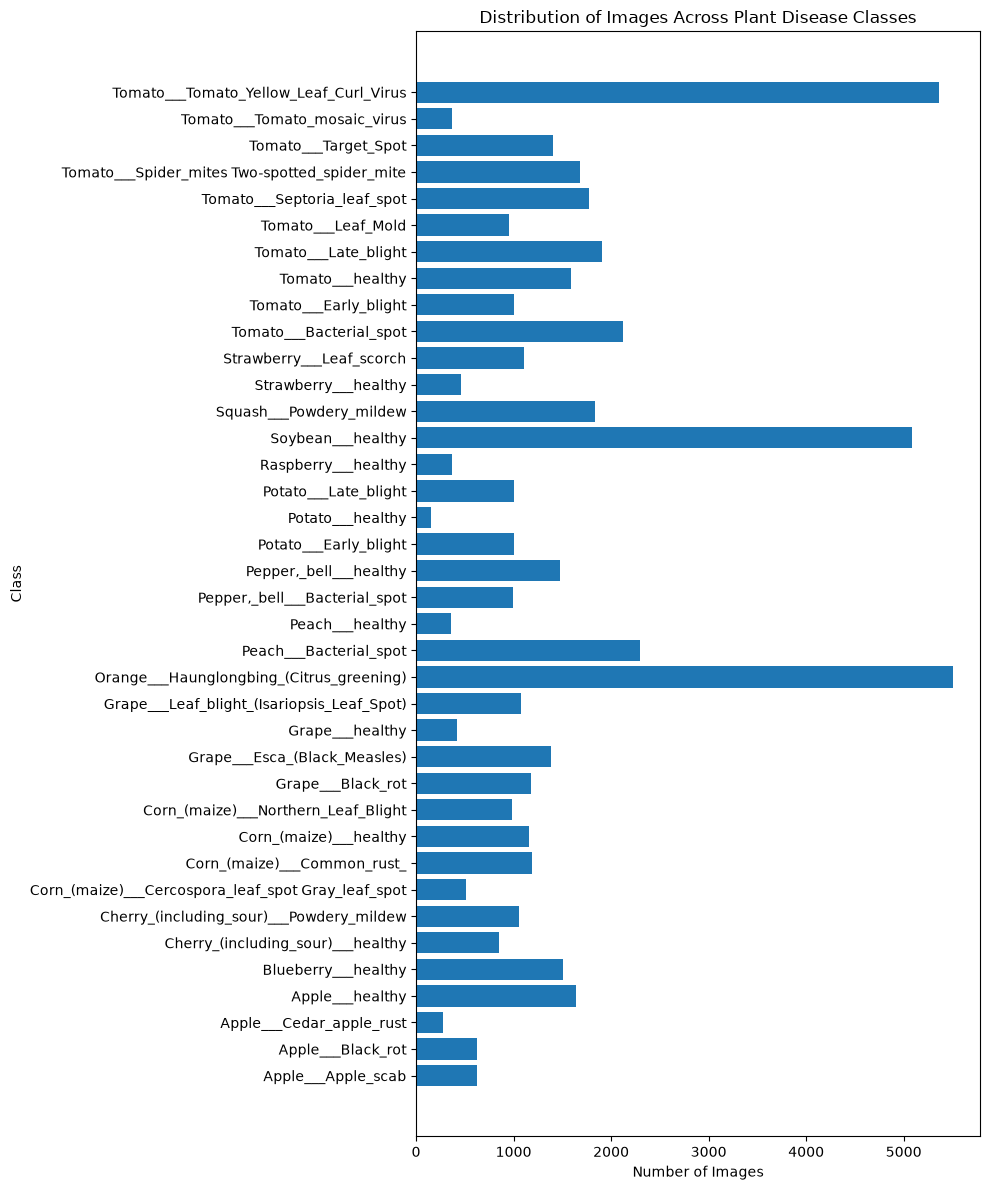

In [11]:
# Checking for class distribution
import matplotlib.pyplot as plt

class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(10, 12))

plt.barh(class_counts.keys(), class_counts.values())

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("Distribution of Images Across Plant Disease Classes")

plt.tight_layout()
plt.show()

The PlantVillage dataset contains 54,305 images distributed across 38 classes. The class distribution is imbalanced, with some classes containing more than 5,000 images while others contain fewer than 200. This imbalance will be considered during model training and evaluation to reduce potential bias toward the majority classes.

In [12]:
# Checking the image dimensions to check if they are consistent or will need to be standardized
from PIL import Image
import random

image_sizes = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    
    # Pick 5 random images from each class
    sample_images = random.sample(os.listdir(class_path), 5)
    
    for image_name in sample_images:
        image_path = os.path.join(class_path, image_name)
        
        with Image.open(image_path) as img:
            image_sizes.append(img.size)

print("Unique image sizes:")
print(set(image_sizes))

Unique image sizes:
{(256, 256)}


In [13]:
# Checking the image channels
class_path = os.path.join(dataset_path, classes[0])

image_name = os.listdir(class_path)[0]
image_path = os.path.join(class_path, image_name)

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (256, 256)
Image mode: RGB


The images were inspected to determine their dimensions and color format. The images have a consistent resolution of 256 × 256 pixels and use the RGB color format with three channels. This consistency simplifies preprocessing before model training.

**Train-Test Split**

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [15]:
# Defining some settings
img_height = 256
img_width = 256
batch_size = 32

For the split we need:

    - Training      70%
    - Validation    15%
    - Testing       15%

In [16]:
# Creating the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.


In [17]:
# Creating the validation and testing dataset
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


In [18]:
# Splitting validation and testing datasets
val_test_batches = tf.data.experimental.cardinality(val_test_ds).numpy()

val_batches = val_test_batches // 2

val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

In [19]:
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 1188
Validation batches: 255
Testing batches: 255


In [20]:
# Checking the class names
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

Currently, RGB pixel values range from 0 to 255. We'll normalize them to 0 to 1 using Rescaling.

In [21]:
# Rescaling the pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1./255)

In [22]:
# Applying it to the three datasets
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [23]:
# Checking if normalization worked
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


**Data Augmentation**

In [24]:
# Creating the data augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.1)
])

RandomFlip("horizontal") → randomly flips some leaves left-to-right.
RandomRotation(0.1) → randomly rotates images slightly.
RandomBrightness(0.1) → randomly changes image brightness slightly.

**Building the CNN model**

In [ ]:
train_ds2 = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.


In [ ]:
val_test_ds2 = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


In [ ]:
val_test_batches = tf.data.experimental.cardinality(val_test_ds2).numpy()

val_batches = val_test_batches // 2

val_ds2 = val_test_ds2.take(val_batches)
test_ds2 = val_test_ds2.skip(val_batches)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

In [ ]:
num_classes = len(class_names)

model2 = tf.keras.Sequential([
    
    # Input
    layers.Input(shape=(256, 256, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from 0-255 to 0-1
    layers.Rescaling(1./255),

    # First convolution
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Second convolution
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Third convolution
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation="relu"),

    # Output
    layers.Dense(num_classes)
])

Adam → updates the model's weights during training.

SparseCategoricalCrossentropy → suitable because we have 38 classes represented by integer labels such as 0, 1, 2, ... 37.

from_logits=True → our final Dense(38) layer doesn't have a softmax activation.

Accuracy → tracks how many images are classified correctly

In [ ]:
model2.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,417,222 (32.11 MB)

 Trainable params: 8,417,222 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

- Input is 256 × 256 × 3 — your RGB leaf images.
- First Conv2D learns 16 feature maps.
- Second learns 32.
- Third learns 64.
- MaxPooling2D progressively reduces the spatial dimensions: 256 → 128 → 64 → 32.
- Flatten converts the final feature maps into 65,536 values.
- Dense(128) learns from those extracted features.
- Dense(38) produces the final scores for your 38 plant/disease classes.

In [ ]:
# Training the improved model
epochs = 10

history2 = model2.fit(
    train_ds2,
    validation_data=val_ds2,
    epochs=epochs
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 446s 375ms/step - accuracy: 0.6372 - loss: 1.2810 - val_accuracy: 0.7870 - val_loss: 0.6813
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 458s 385ms/step - accuracy: 0.8338 - loss: 0.5376 - val_accuracy: 0.8376 - val_loss: 0.5153
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 459s 386ms/step - accuracy: 0.8793 - loss: 0.3726 - val_accuracy: 0.8336 - val_loss: 0.5502
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 487s 410ms/step - accuracy: 0.9014 - loss: 0.3022 - val_accuracy: 0.8974 - val_loss: 0.3123
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 463s 389ms/step - accuracy: 0.9172 - loss: 0.2522 - val_accuracy: 0.8675 - val_loss: 0.4332
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 693s 584ms/step - accuracy: 0.9260 - loss: 0.2242 - val_accuracy: 0.8973 - val_loss: 0.3359
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 935s 746ms/step - accuracy: 0.9365 - loss: 0.1968 - val_accuracy: 0.8996 - val_loss: 0.3186
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 772s 649ms/step - ac

The CNN model was trained for 10 epochs. Training accuracy increased from 63.72% in the first epoch to 94.88% in the final epoch, while training loss decreased from 1.2810 to 0.1517. This indicates that the model progressively learned useful features from the plant images.
Validation accuracy also improved during training, reaching its highest value of 93.52% at epoch 8. The final validation accuracy was 91.30%. Overall, the model showed strong learning performance, although some fluctuations in validation accuracy and loss were observed in the later epochs.

In [ ]:
acc = history2.history["accuracy"]
val_acc = history2.history["val_accuracy"]

loss = history2.history["loss"]
val_loss = history2.history["val_loss"]

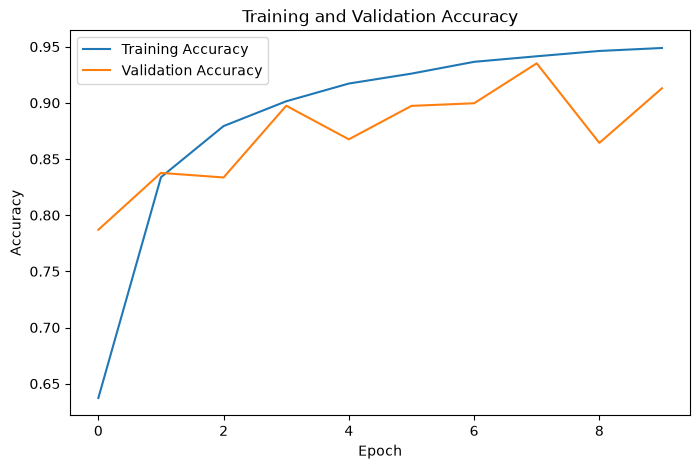

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

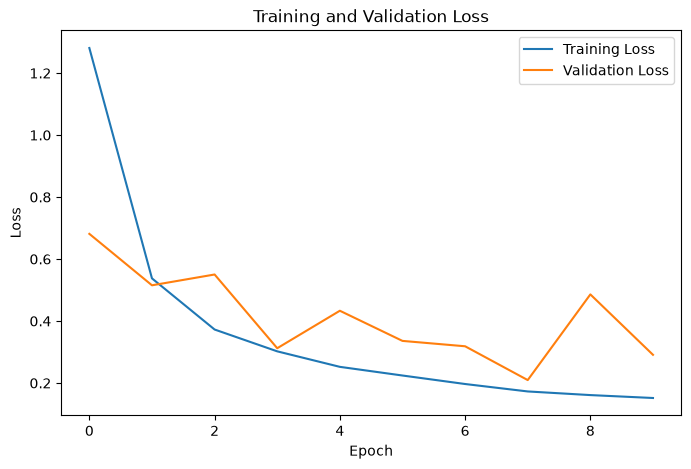

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

The accuracy graph shows a consistent increase in training accuracy across the epochs, while validation accuracy generally improved but showed some fluctuations. The training and validation accuracy remained relatively close for most epochs, indicating that the model generalized reasonably well to unseen validation data.
The loss graph shows that training loss consistently decreased as the model learned. Validation loss also generally decreased but fluctuated during some epochs. The increase in validation loss around epoch 9, while training loss continued to decrease, suggests slight overfitting in the later stages of training. The strongest validation performance was observed around epoch 8.

In [ ]:
# Evaluating the model on the test dataset
test_loss, test_accuracy = model2.evaluate(test_ds2)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

255/255 ━━━━━━━━━━━━━━━━━━━━ 66s 239ms/step - accuracy: 0.9044 - loss: 0.3366
Test Accuracy: 0.9044398069381714
Test Loss: 0.336567759513855


The trained CNN achieved a test accuracy of 90.44% with a test loss of 0.3366. The test accuracy was relatively close to the training accuracy of 94.88% and validation accuracy of 91.30%, indicating that the model generalizes well to unseen plant images.

**Classification Report**

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds2:
    
    predictions = model2.predict(images, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.76      0.82        93
                                 Apple___Black_rot       0.73      0.99      0.84        99
                          Apple___Cedar_apple_rust       1.00      0.82      0.90        40
                                   Apple___healthy       0.85      0.92      0.89       248
                               Blueberry___healthy       0.99      0.83      0.91       218
          Cherry_(including_sour)___Powdery_mildew       0.99      0.95      0.97       182
                 Cherry_(including_sour)___healthy       0.99      0.92      0.95       130
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.50      0.92      0.64        84
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       163
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.43      0.

The CNN achieved an overall test accuracy of 90%, with a weighted precision of 92%, recall of 90%, and F1-score of 90%. Most plant-disease classes were classified accurately, with several achieving F1-scores above 0.90. However, performance was lower for some classes, including Corn Northern Leaf Blight, Corn Cercospora Leaf Spot, Potato Healthy, and Tomato Early Blight. The macro-average F1-score of 87%, compared with the weighted F1-score of 90%, indicates some variation in performance across the 38 classes, which may partly reflect the class imbalance observed during exploratory data analysis.

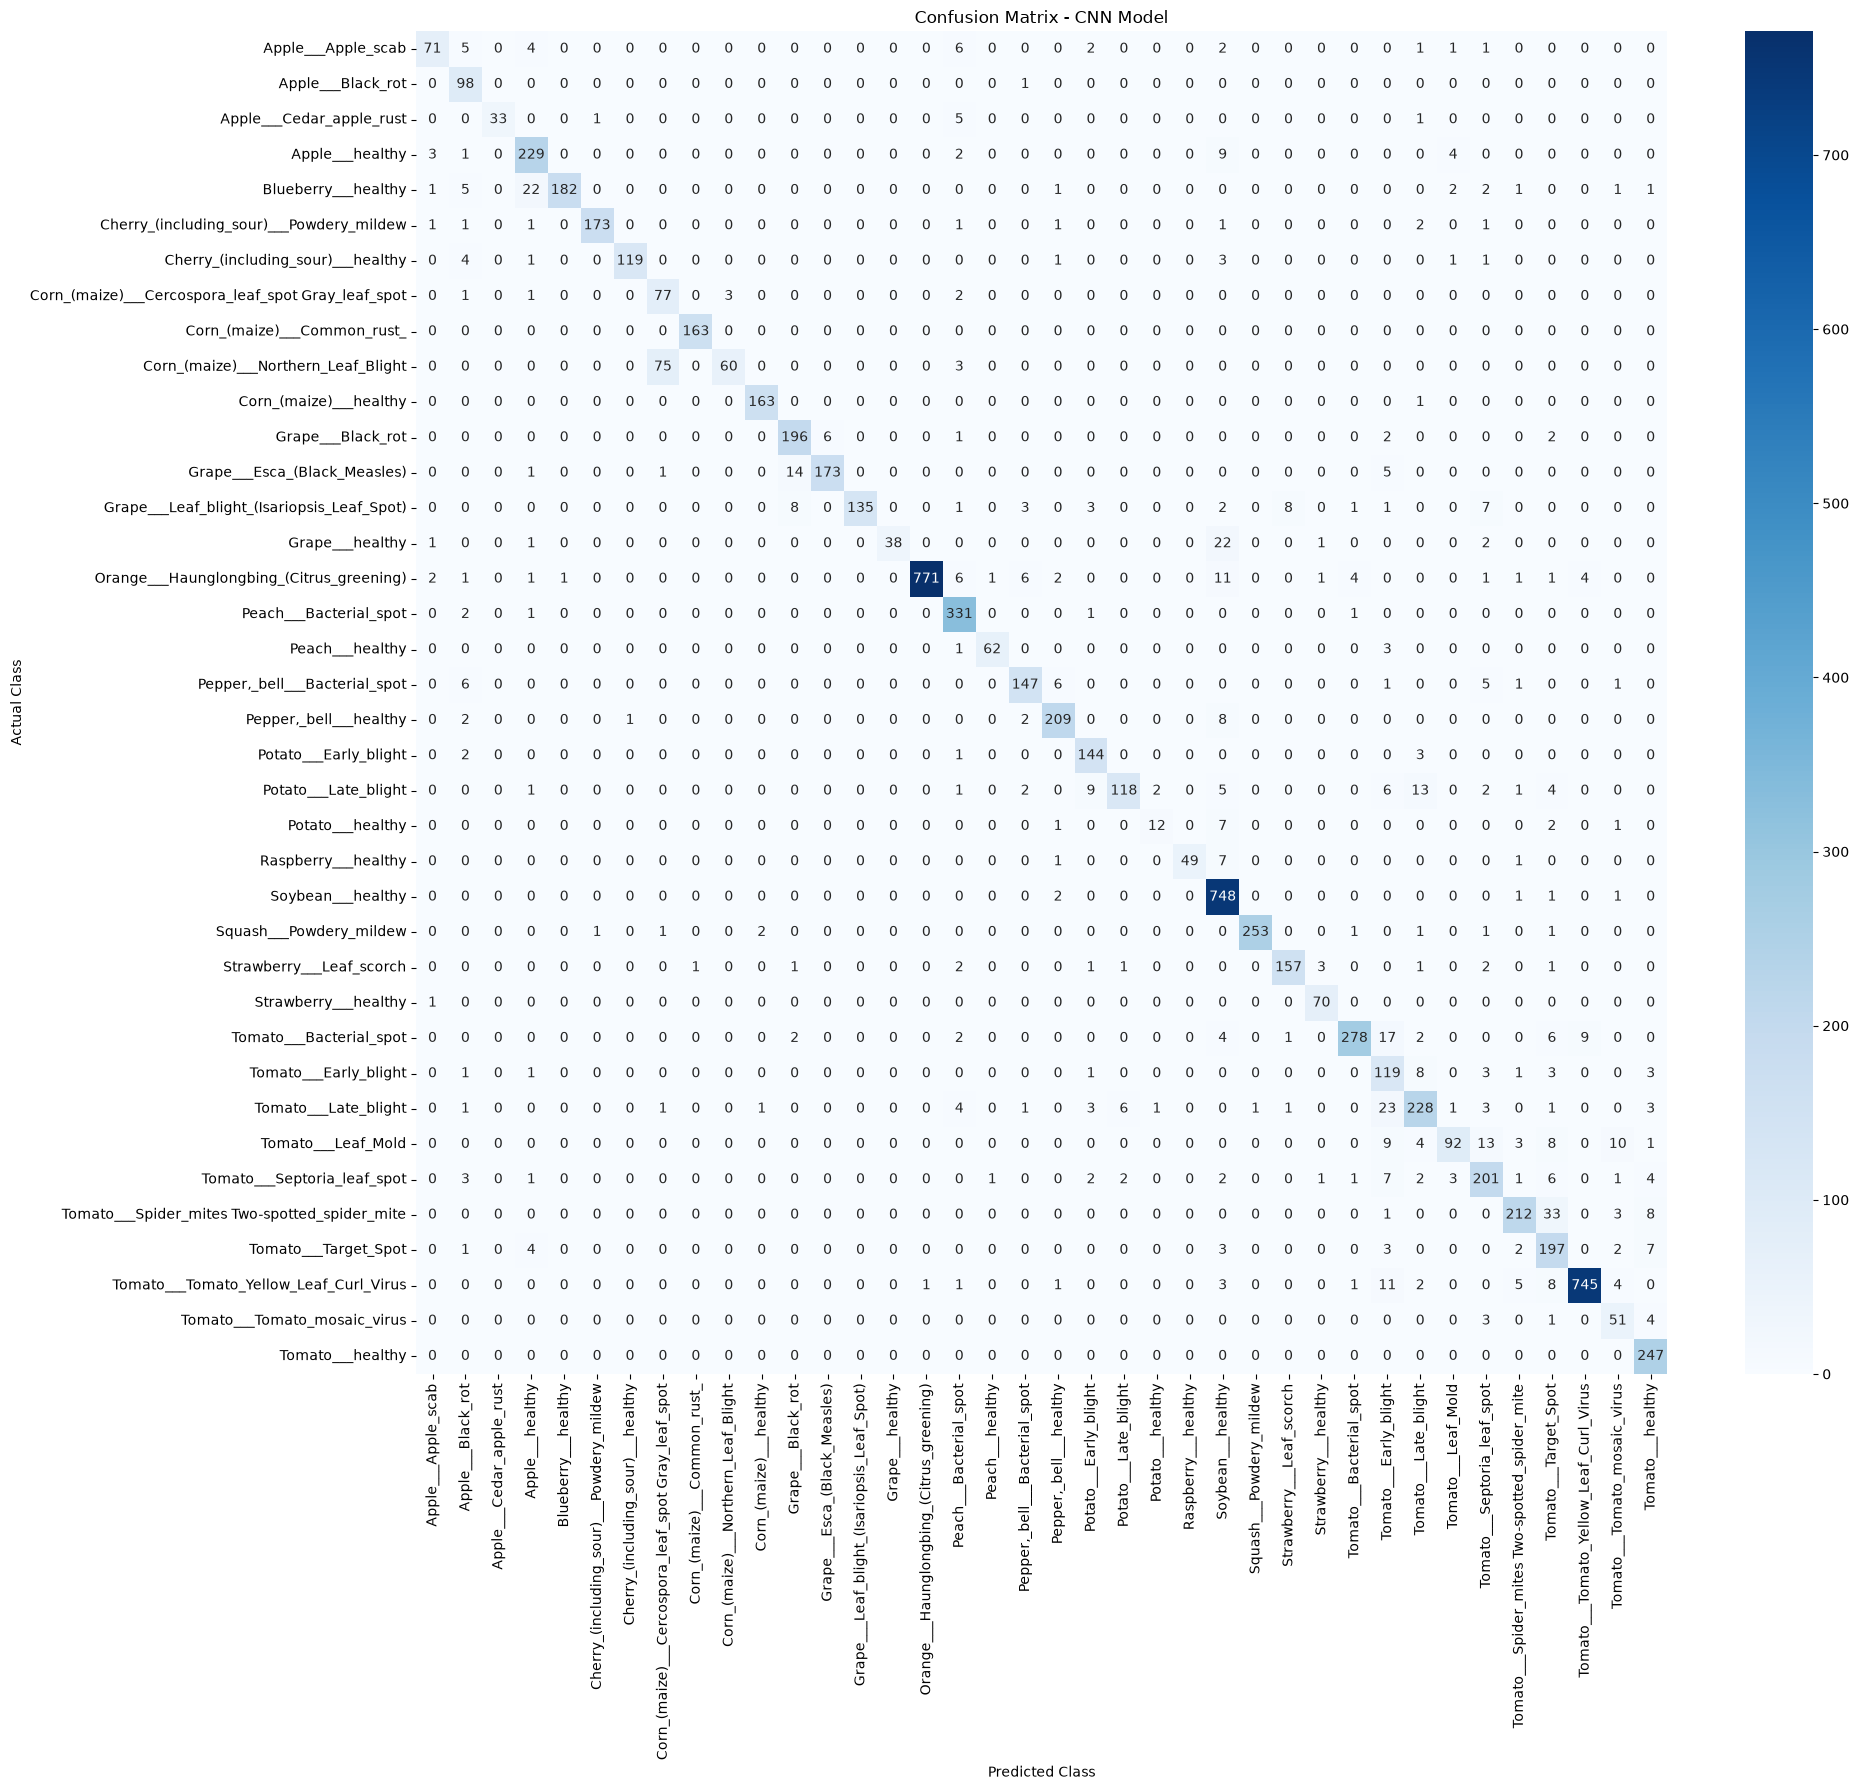

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The confusion matrix shows that most predictions are concentrated along the main diagonal, indicating that the CNN correctly classified the majority of test images. However, some misclassification occurred between visually related disease classes. A notable example is Corn Northern Leaf Blight, where many images were incorrectly classified as Corn Cercospora/Gray Leaf Spot. Some confusion was also observed among tomato disease classes. Overall, the confusion matrix supports the strong test performance of the model while highlighting specific classes where further improvement may be needed.

**Actual vs Predicted images**

This visualization lets us visually inspect individual predictions and see examples of where the CNN succeeds or fails.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


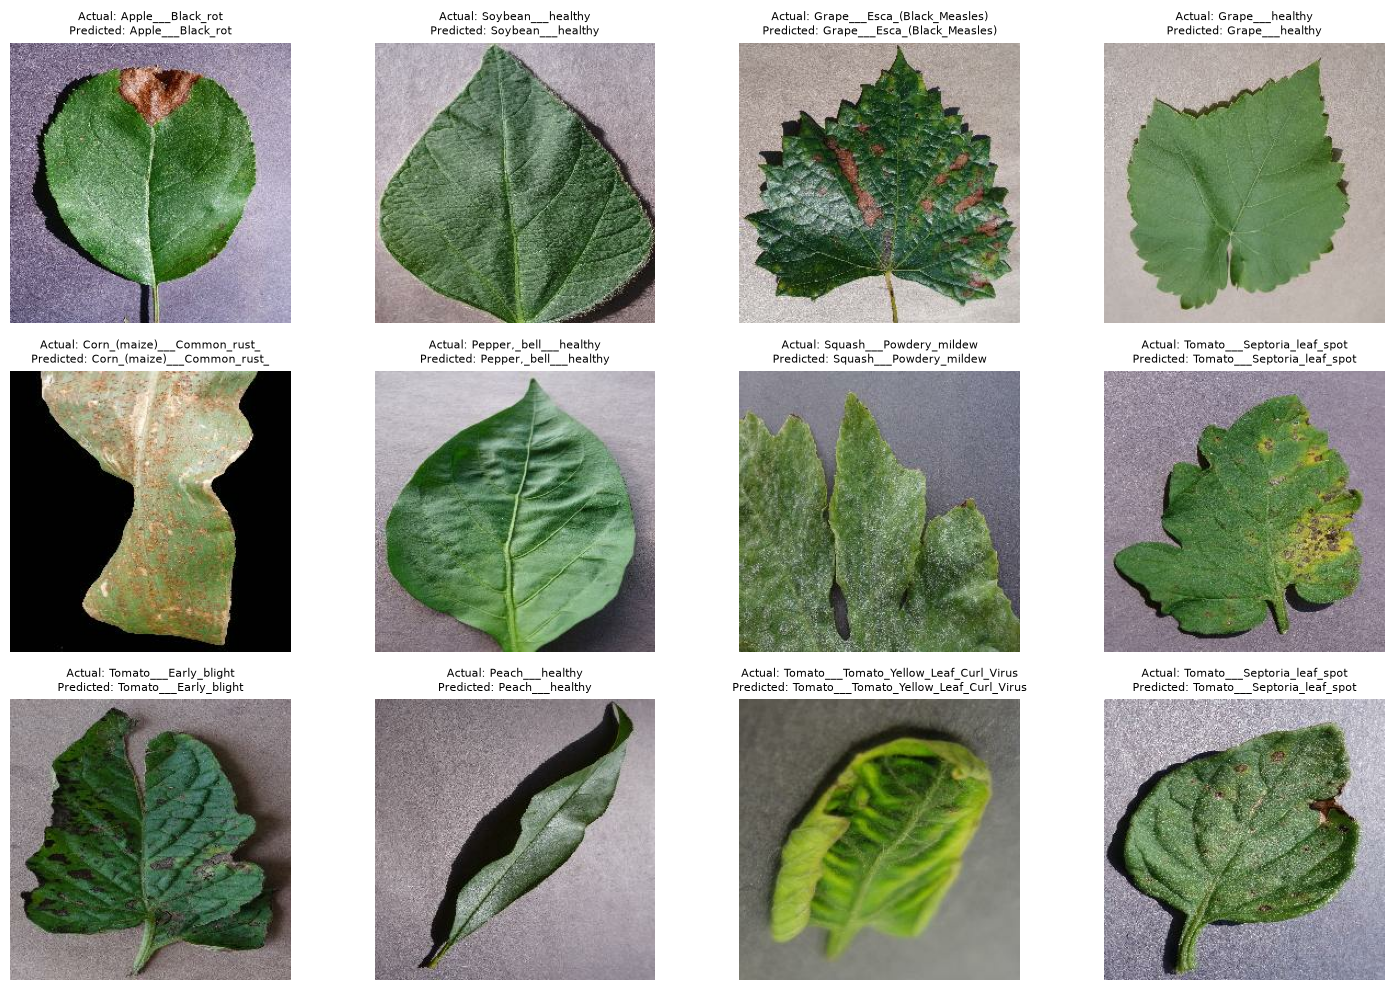

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the test dataset
for images, labels in test_ds2.take(1):
    
    predictions = model2.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 10))

    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_labels[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}",
            fontsize=8
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

The sample predictions demonstrate the CNN model's ability to correctly classify different plant species and disease conditions from unseen test images. In the displayed examples, the predicted labels matched the actual labels, including both healthy plants and diseased leaves such as Apple Black Rot, Grape Black Measles, Corn Common Rust, Squash Powdery Mildew, Tomato Early Blight and Tomato Septoria Leaf Spot. These examples provide a visual demonstration of the model's strong classification performance.